# Algoritmos No Supervisados

**Objetivo:** Introducir los conceptos fundamentales y la aplicación práctica de algoritmos de aprendizaje no supervisado utilizando Python y bibliotecas populares como Scikit-learn, Pandas y NumPy.

**Temas Cubiertos:**
1.  Clustering (Agrupamiento)
    *   K-Means
    *   Aglomerativo Jerárquico
    *   DBSCAN
2.  Reducción de la Dimensionalidad
    *   Análisis de Componentes Principales (PCA)
    *   t-SNE (para visualización)
3.  Ejercicio Práctico: Clustering aplicado a Churn

## 0. Configuración Inicial

Primero, importaremos las bibliotecas necesarias para nuestro análisis.
*   **Pandas:** Para manipulación y análisis de datos (especialmente DataFrames).
*   **NumPy:** Para operaciones numéricas eficientes, especialmente con arrays.
*   **Scikit-learn:** La biblioteca principal para machine learning en Python, que usaremos para clustering y reducción de dimensionalidad.
*   **Matplotlib & Seaborn:** Para visualización de datos.
*   **SciPy:** La usaremos específicamente para el dendrograma en clustering jerárquico.

In [53]:
# Importación de librerías
import pandas as pd
import numpy as np

# Para Clustering y Reducción de Dimensionalidad
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.preprocessing import StandardScaler, OneHotEncoder # Para escalar datos numéricos y codificar categóricos si fuera necesario
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score # Para evaluar clusters

# Para visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Para clustering jerárquico y dendrogramas
from scipy.cluster.hierarchy import dendrogram, linkage

# Configuraciones adicionales para visualización
%matplotlib inline
sns.set(style="whitegrid")

## 1. Clustering (Agrupamiento)

El clustering es una técnica de aprendizaje no supervisado cuyo objetivo es encontrar grupos (clusters) naturales en los datos: los puntos dentro de un mismo grupo deben ser más similares entre sí que con los puntos de otros grupos. No tenemos etiquetas predefinidas — el algoritmo las descubre solo.

---

### ¿Qué significa "similitud"?

Para agrupar datos, los algoritmos necesitan una medida de qué tan parecidos son dos puntos. Las métricas de distancia más comunes son:

- **Distancia Euclidiana:** la "distancia en línea recta" entre dos puntos en el espacio. La más común y la que usa K-Means por defecto.
- **Distancia Manhattan:** suma de las diferencias absolutas en cada dimensión (como moverse en una grilla de ciudad).
- **Distancia de Coseno:** mide el ángulo entre dos vectores, no su magnitud. Útil en texto y datos de alta dimensionalidad.

La elección de la métrica afecta directamente los resultados: un clustering con distancia euclidiana puede dar grupos muy distintos al mismo clustering con distancia coseno.

---

### Familias principales de algoritmos de clustering

| Familia | Ejemplos | Forma de clusters | Necesita K? |
|---------|---------|-------------------|-------------|
| **Partición** | K-Means, K-Medoids | Esférica/convexa | Sí |
| **Jerárquico** | Aglomerativo, Divisivo | Cualquier forma | No (lee el dendrograma) |
| **Basado en densidad** | DBSCAN, HDBSCAN | Arbitraria, con ruido | No |
| **Modelos de mezcla** | GMM (Gaussian Mixture) | Elíptica | Sí |

---

### Preprocesamiento: siempre escalar antes de clustering

La mayoría de los algoritmos de clustering usan distancias. Si una variable tiene rango [0-1000] y otra [0-1], la primera va a dominar completamente el cálculo. Por eso es obligatorio estandarizar los datos antes de aplicar cualquier algoritmo basado en distancias.

```python
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # media=0, std=1 por columna
```

---

### Aplicaciones en la industria

- **Retail y e-commerce:** Segmentación de clientes por comportamiento de compra.
- **Marketing:** Identificación de perfiles de usuarios para campañas personalizadas.
- **Medicina:** Clasificación de pacientes por síntomas para diagnóstico diferencial.
- **Ciberseguridad:** Detección de anomalías agrupando patrones de tráfico de red.
- **Imágenes:** Compresión de imágenes reduciendo colores similares a un mismo cluster.

---

### Evaluación: ¿cómo sé si el clustering es bueno?

A diferencia del aprendizaje supervisado, no hay una "respuesta correcta" para comparar. Las métricas internas más usadas son:
- **Inercia / WCSS:** suma de distancias al centroide (menor = más compacto).
- **Coeficiente Silhouette:** mide cohesión interna vs separación entre clusters (mayor = mejor).
- **Davies-Bouldin Index:** promedio de similitud entre clusters vecinos (menor = mejor).

### 1.1. K-Means (No Jerárquico)

**Concepto:**
K-Means es uno de los algoritmos de clustering más populares. Funciona así:
1.  **Elige K:** Se especifica el número de clusters deseados.
2.  **Inicialización:** Se seleccionan K centroides iniciales. Con **K-Means++** (por defecto en scikit-learn), los centroides iniciales se eligen bien separados entre sí, mejorando la convergencia.
3.  **Asignación:** Cada punto se asigna al cluster cuyo centroide esté más cercano (distancia euclidiana).
4.  **Actualización:** Los centroides se recalculan como la media de todos los puntos asignados.
5.  **Iteración:** Los pasos 3 y 4 se repiten hasta que los centroides no cambien o se alcance el máximo de iteraciones.

**Función objetivo — WCSS:**
K-Means minimiza la **Suma de Cuadrados Intra-Cluster (WCSS)**:

`WCSS = Σk Σ(xi ∈ Ck) ‖xi − μk‖²`

Cuanto menor el WCSS, más compactos son los clusters. El WCSS siempre baja al subir K (con K=N, cada punto sería su propio cluster y WCSS=0), por eso se usa el método del codo.

---

**Métodos para elegir K:**

**1. Método del Codo (Elbow Method):**
Graficamos WCSS vs K. Buscamos el punto donde la curva "codo" empieza a aplanarse — allí agregar más clusters ya no reduce mucho el WCSS.

**2. Coeficiente Silhouette:**
Para cada punto `i`:
- `a(i)` = distancia promedio al resto de puntos en su mismo cluster (cohesión interna)
- `b(i)` = distancia promedio al cluster vecino más cercano (separación)

`s(i) = (b(i) − a(i)) / max(a(i), b(i))`

El **Silhouette Score promedio** del dataset va de -1 a 1:
- Cerca de **1** → clusters bien separados y compactos
- Cerca de **0** → puntos en el borde entre clusters
- **Negativo** → el punto probablemente está en el cluster equivocado

| Método | Cuándo usarlo |
|--------|-------------|
| Codo (WCSS) | Siempre, como primer paso |
| Silhouette | Para validar la elección con más rigor |
| Ambos | Si coinciden → mayor confianza en K |

---

**Ventajas:**
*   Simple, escalable y computacionalmente eficiente.
*   K-Means++ reduce la sensibilidad a la inicialización aleatoria.
*   Fácil de interpretar: cada cluster tiene un centroide claro.

**Desventajas:**
*   Requiere especificar K de antemano.
*   Asume clusters esféricos y de densidad similar.
*   Sensible a outliers y a la escala de las variables (¡siempre escalar antes!).

In [ ]:
# Ejemplo Ilustrativo de K-Means
# Dataset: Mediciones climáticas sintéticas de 240 ciudades
# Variables: Temperatura promedio anual (°C) y Humedad relativa media (%)

np.random.seed(42)
n = 80  # ciudades por grupo

# Grupo 1: Ciudades tropicales — cálidas y húmedas
tropicales = np.random.multivariate_normal([29, 78], [[4, 3], [3, 12]], n)
# Grupo 2: Ciudades templadas — temperatura y humedad moderadas
templadas  = np.random.multivariate_normal([14, 55], [[6, -2], [-2, 10]], n)
# Grupo 3: Ciudades áridas — cálidas y muy secas
aridas     = np.random.multivariate_normal([26, 18], [[5, 1], [1, 8]], n)

X_clima = np.vstack([tropicales, templadas, aridas])
X_clima[:, 1] = np.clip(X_clima[:, 1], 0, 100)  # Humedad ∈ [0%, 100%]

# Graficamos SIN etiquetas — como en un escenario real no supervisado
plt.figure(figsize=(8, 6))
plt.scatter(X_clima[:, 0], X_clima[:, 1], s=50, color='steelblue',
            alpha=0.6, edgecolor='k', linewidth=0.4)
plt.title("Datos climáticos de 240 ciudades (sin etiquetas)\n"
          "K-Means tiene que descubrir los grupos por sí solo")
plt.xlabel("Temperatura promedio anual (°C)")
plt.ylabel("Humedad relativa media (%)")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# Escalar antes de aplicar K-Means (fundamental: evita que la temperatura domine sobre la humedad)
scaler_clima = StandardScaler()
X_clima_scaled = scaler_clima.fit_transform(X_clima)

# Aplicar K-Means con k=3
kmeans_clima = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_clima.fit(X_clima_scaled)
y_kmeans_clima = kmeans_clima.predict(X_clima_scaled)

# Centroides en la escala original (interpretables)
centers_clima = scaler_clima.inverse_transform(kmeans_clima.cluster_centers_)
print("Centroides encontrados por K-Means (escala original):")
for i, c in enumerate(centers_clima):
    print(f"  Cluster {i}: Temperatura = {c[0]:.1f}°C | Humedad = {c[1]:.1f}%")

In [ ]:
# Graficar los clusters encontrados
colores_clima = ['#e74c3c', '#2ecc71', '#3498db']  # rojo, verde, azul

plt.figure(figsize=(8, 6))
for cluster_id in range(3):
    mask = y_kmeans_clima == cluster_id
    plt.scatter(X_clima[mask, 0], X_clima[mask, 1],
                c=colores_clima[cluster_id], s=55, alpha=0.7,
                edgecolor='k', linewidth=0.4, label=f'Cluster {cluster_id}')

plt.scatter(centers_clima[:, 0], centers_clima[:, 1],
            c='black', s=280, marker='X', zorder=5, label='Centroides')

plt.title("K-Means (k=3) — Datos Climáticos")
plt.xlabel("Temperatura promedio anual (°C)")
plt.ylabel("Humedad relativa media (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("Comparación con la realidad:")
print("  Cluster de alta humedad + alta temp → Tropical")
print("  Cluster de temperatura media + humedad media → Templado")
print("  Cluster de baja humedad + alta temp → Árido")

In [ ]:
# Método del Codo — dataset climático
inertia = []
k_range = range(1, 11)

for k in k_range:
    km_elbow = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_elbow.fit(X_clima_scaled)
    inertia.append(km_elbow.inertia_)

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o', color='steelblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='Codo en k=3')
plt.title('Método del Codo — Dataset Climático')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia (WCSS)')
plt.xticks(k_range)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
print("El codo aparece en k=3, consistente con los 3 tipos de clima del dataset.")

In [ ]:
# ── Validación con Coeficiente Silhouette ─────────────────────────────────
# Calculamos Silhouette Score para cada k y lo comparamos con el codo

silhouette_avgs = []
k_sil_range = range(2, 11)  # Silhouette no aplica para k=1

for k in k_sil_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_clima_scaled)
    silhouette_avgs.append(silhouette_score(X_clima_scaled, labels_k))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Inercia (codo)
ax1.plot(k_range, inertia, 'bo-', markersize=8, linewidth=2)
ax1.axvline(x=3, color='red', linestyle='--', alpha=0.7, label='k=3')
ax1.set_title('Método del Codo (Inercia)');  ax1.set_xlabel('k');  ax1.set_ylabel('Inercia')
ax1.legend();  ax1.grid(True, alpha=0.3)

# Silhouette
best_k = list(k_sil_range)[np.argmax(silhouette_avgs)]
ax2.plot(k_sil_range, silhouette_avgs, 'rs-', markersize=8, linewidth=2)
ax2.axvline(x=best_k, color='blue', linestyle='--', alpha=0.7, label=f'Mejor k={best_k}')
ax2.set_title('Coeficiente Silhouette Promedio');  ax2.set_xlabel('k');  ax2.set_ylabel('Silhouette Score')
ax2.legend();  ax2.grid(True, alpha=0.3)

plt.suptitle('Comparación de métricas para elegir k óptimo', fontsize=13)
plt.tight_layout()
plt.show()

print(f"Mejor k según Silhouette: k={best_k}  (Score={max(silhouette_avgs):.3f})")
print("Cuando codo y Silhouette coinciden en el mismo k → mayor confianza en la elección.")

### 1.2. Clustering Jerárquico (Aglomerativo)

**Concepto:**
El clustering aglomerativo es un enfoque "bottom-up" (de abajo hacia arriba): comienza tratando cada punto como su propio cluster, y en cada paso fusiona los dos clusters más cercanos hasta que todos quedan en uno solo. El resultado es una **jerarquía completa** de fusiones.

**Algoritmo paso a paso:**
1.  **Inicio:** N puntos → N clusters (cada punto es su propio cluster).
2.  **Calcular distancias:** Se construye una matriz de distancias entre todos los pares de clusters.
3.  **Fusionar:** Los dos clusters con menor distancia se combinan en uno.
4.  **Actualizar:** Se recalculan las distancias al nuevo cluster (según el método de linkage).
5.  **Repetir** hasta que quede un único cluster.

---

**Métodos de Linkage:**
El linkage define cómo se mide la "distancia" entre dos clusters:

| Método | Cálculo | Característica |
|--------|---------|----------------|
| **Ward** | Minimiza el aumento de varianza interna al fusionar | Clusters compactos y esféricos. El más usado. |
| **Complete** | Distancia máxima entre puntos de dos clusters | Clusters de tamaño similar, menos sensible a outliers que Single |
| **Average** | Distancia promedio entre todos los pares | Balance entre Ward y Single |
| **Single** | Distancia mínima entre puntos de dos clusters | Sensible a outliers → crea "cadenas" largas (efecto de encadenamiento) |

---

**El Dendrograma:**
Es la visualización clave del clustering jerárquico. Es un árbol donde:
- Cada **hoja** = un punto de datos original.
- La **altura de cada fusión** = distancia a la que se unieron esos dos clusters.
- **Cortar el dendrograma** a una altura determina el número de clusters.

Para elegir el número de clusters: buscar la fusión más "alta" (mayor gap vertical) que no cruce ninguna línea horizontal. Ese es el punto más natural de corte.

---

**Complejidad computacional:**
- Memoria: O(n²) — almacena la matriz de distancias completa.
- Tiempo: O(n² log n) con Ward; O(n³) con métodos simples.
- **Limite práctico:** funciona bien hasta ~10.000 puntos. Para datasets grandes, usar K-Means o DBSCAN.

---

**¿Cuándo preferir Jerárquico sobre K-Means?**
- Cuando no sabés de antemano cuántos clusters hay (el dendrograma lo revela).
- Cuando querés explorar la estructura a múltiples escalas de resolución.
- Cuando el dataset es pequeño o mediano (<10K puntos).
- Cuando el resultado necesita ser explicable visualmente (el dendrograma es muy intuitivo).

**¿Cuándo preferir K-Means?**
- Datasets grandes (>50K puntos).
- Cuando ya sabés cuántos clusters querés.
- Cuando necesitás un resultado rápido y reproducible.

---

**Ventajas:**
*   No requiere K de antemano — el dendrograma guía la elección.
*   El resultado es determinístico (no depende de inicialización aleatoria).
*   Produce clusters a múltiples niveles de granularidad.

**Desventajas:**
*   Computacionalmente caro para datasets grandes.
*   Las fusiones son **irreversibles** — un error temprano no se puede corregir.
*   Sensible a outliers (especialmente con Single linkage).

In [ ]:
# Usamos los mismos datos climáticos que K-Means — así podemos comparar ambos resultados

# Submuestra de 60 ciudades para que el dendrograma sea legible
np.random.seed(7)
idx_sample = np.random.choice(len(X_clima), 60, replace=False)
X_demo_small = X_clima[idx_sample]

# Calcular la matriz de enlace con Ward
linked_clima = linkage(X_demo_small, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(linked_clima,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True,
           color_threshold=25)

plt.title('Dendrograma — Datos Climáticos (muestra de 60 ciudades)')
plt.xlabel('Índice de la ciudad')
plt.ylabel('Distancia (Ward)')
plt.axhline(y=25, color='red', linestyle='--', linewidth=1.5, label='Corte → 3 clusters')
plt.legend()
plt.show()

print("Cortando en altura ≈ 25 → 3 grupos.  Consistente con K-Means y los grupos reales.")
print("Sin haber especificado k=3, el dendrograma lo revela visualmente.")

In [ ]:
# AgglomerativeClustering con n_clusters=3 sobre todos los datos climáticos
from sklearn.metrics import adjusted_rand_score

agg_clima = AgglomerativeClustering(n_clusters=3, linkage='ward')
y_agg_clima = agg_clima.fit_predict(X_clima)

colores_agg = ['#e74c3c', '#2ecc71', '#3498db']
plt.figure(figsize=(8, 6))
for cluster_id in range(3):
    mask = y_agg_clima == cluster_id
    plt.scatter(X_clima[mask, 0], X_clima[mask, 1],
                c=colores_agg[cluster_id], s=55, alpha=0.7,
                edgecolor='k', linewidth=0.4, label=f'Cluster {cluster_id}')

plt.title("Clustering Jerárquico (Ward, k=3) — Datos Climáticos")
plt.xlabel("Temperatura promedio anual (°C)")
plt.ylabel("Humedad relativa media (%)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Comparación cuantitativa con K-Means
ari = adjusted_rand_score(y_kmeans_clima, y_agg_clima)
print(f"Adjusted Rand Index (K-Means vs Jerárquico): {ari:.3f}")
print("ARI cercano a 1.0 → ambos métodos encontraron prácticamente los mismos grupos.")
print("ARI = 0 → asignación aleatoria.  ARI < 0 → peor que el azar.")

### 1.3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Concepto:**
DBSCAN agrupa puntos densamente empaquetados y marca como **ruido** los que están solos en regiones de baja densidad. Clasifica cada punto en una de tres categorías:

- **Core Point (Punto Núcleo):** Tiene al menos `min_samples` vecinos dentro del radio `eps`.
- **Border Point (Punto de Borde):** No es núcleo, pero está dentro del radio de un punto núcleo.
- **Noise (Ruido):** No es núcleo ni alcanzable desde ningún punto núcleo — se etiqueta como -1.

**Parámetros clave:**
1.  **`eps` (epsilon):** Radio de vecindad. Si es muy pequeño → casi todo es ruido. Si es muy grande → todo queda en un solo cluster.
2.  **`min_samples`:** Mínimo de puntos para que un punto sea "núcleo". Regla práctica: `min_samples ≥ n_features + 1` (para datos 2D, usar al menos 3).

**Cómo elegir `eps` — K-Distance Plot:**
1. Para cada punto, calcular la distancia al k-ésimo vecino más cercano (con k = min_samples - 1).
2. Graficar esas distancias ordenadas de menor a mayor.
3. El "codo" en esa curva es un buen valor de `eps`.

**Ventajas:**
*   No requiere especificar el número de clusters.
*   Detecta clusters de **forma arbitraria** (no solo esféricos).
*   Robusto frente a outliers: los identifica explícitamente como ruido.

**Desventajas:**
*   Difícil de parametrizar cuando los clusters tienen **densidades muy distintas**.
*   Sensible a `eps` y `min_samples` — requiere experimentación.
*   Problemas con datos de alta dimensionalidad (maldición de la dimensionalidad).

**¿Cuándo usar DBSCAN en lugar de K-Means?**
| Situación | Mejor opción |
|-----------|-------------|
| Clusters esféricos, tamaño similar | K-Means |
| Clusters de forma irregular (lunas, espirales) | DBSCAN |
| Datos con ruido/outliers significativos | DBSCAN |
| Se necesita interpretar centroides | K-Means |
| No sé cuántos clusters hay | DBSCAN o Jerárquico |

### 1.3. DBSCAN (Density-Based Spatial Clustering of Applications with Noise)

**Concepto:**
DBSCAN agrupa puntos que están densamente empaquetados, marcando como ruido los puntos que se encuentran solos en regiones de baja densidad. Se basa en dos parámetros:
1.  **`eps` (epsilon):** La distancia máxima entre dos muestras para que una se considere vecina de la otra.
2.  **`min_samples`:** El número de muestras (o peso total) en una vecindad para que un punto sea considerado como un punto *núcleo* (core point).

El algoritmo funciona así:
1.  Se elige un punto arbitrario no visitado.
2.  Si el punto es un *punto núcleo* (tiene al menos `min_samples` vecinos dentro de la distancia `eps`), se inicia un nuevo cluster. Todos los puntos densamente alcanzables desde este punto se añaden al cluster.
3.  Si el punto no es núcleo, se marca temporalmente como ruido (podría ser añadido a un cluster más tarde si es alcanzado por otro punto núcleo).
4.  Se repite el proceso hasta que todos los puntos han sido visitados.

**Ventajas:**
*   No requiere especificar el número de clusters.
*   Puede encontrar clusters de formas arbitrarias.
*   Robusto frente a outliers (los identifica como ruido).

**Desventajas:**
*   No funciona bien con clusters de densidades variables.
*   Sensible a los parámetros `eps` y `min_samples`. Encontrar buenos valores puede ser difícil.
*   Puede tener problemas con datos de muy alta dimensionalidad (la "maldición de la dimensionalidad").

In [63]:
# Generar datos con forma no esférica (lunas)
X_moons, y_moons_true = make_moons(n_samples=250, noise=0.1, random_state=42)

# Escalar los datos (aunque DBSCAN es menos sensible a la escala que K-Means, sigue siendo buena práctica)
scaler_moons = StandardScaler()
X_moons_scaled = scaler_moons.fit_transform(X_moons)

## 2. Reducción de la Dimensionalidad

Cuando trabajamos con datasets de alta dimensionalidad (muchas variables) enfrentamos la **"maldición de la dimensionalidad"**: las distancias se vuelven poco informativas, el costo computacional crece exponencialmente y es imposible visualizar los datos. La reducción de dimensionalidad busca comprimir la información manteniendo lo más importante.

---

### 2.1. Análisis de Componentes Principales (PCA)

**Concepto:**
PCA es una técnica **lineal** que transforma las variables originales en nuevas variables ortogonales (no correlacionadas) llamadas **Componentes Principales (PCs)**. Cada PC captura la mayor varianza posible que no fue capturada por los componentes anteriores.

**Pasos del algoritmo:**
1.  Estandarizar los datos (media=0, varianza=1) — **obligatorio**, PCA es sensible a la escala.
2.  Calcular la **matriz de covarianza** (resume cómo varían las variables juntas).
3.  Calcular los **eigenvectores y eigenvalores** de esa matriz.
4.  Los eigenvectores definen las direcciones de los nuevos ejes (PCs). El eigenvalor de cada uno indica cuánta varianza captura.
5.  Proyectar los datos originales sobre los primeros k PCs para reducir a k dimensiones.

**¿Cuántos componentes elegir?**
- **Scree Plot:** Graficar la varianza explicada por cada PC. Elegir el punto donde la curva se aplana.
- **Varianza acumulada:** Elegir suficientes componentes para explicar ≥90% (o ≥95%) de la varianza total.

**Lectura del mapa de Loadings:**
Los **loadings** muestran cuánto contribuye cada variable original a cada PC. Un loading cercano a ±1 significa alta contribución; cercano a 0 significa que esa variable casi no participa en ese componente.

**Ventajas:**
*   Elimina la redundancia (correlaciones entre variables).
*   Mejora el rendimiento de otros algoritmos al reducir ruido.
*   Permite visualizar datos complejos en 2D/3D.

**Desventajas:**
*   Solo captura relaciones **lineales**. Para relaciones no lineales → usar Kernel PCA o t-SNE.
*   Los componentes resultantes son difíciles de interpretar (son combinaciones de todas las variables).
*   Sensible a la escala → siempre estandarizar antes.

**PCA vs t-SNE:**
| | PCA | t-SNE |
|-|-----|-------|
| Tipo | Lineal | No lineal |
| Uso | Reducción + preprocesamiento | Visualización 2D/3D |
| Distancias globales | Se preservan razonablemente | No confiables |
| Velocidad | Muy rápido | Lento en datasets grandes |
| Reproducible | Sí | Depende de la semilla |

In [64]:
# Aplicar DBSCAN
# Encontrar buenos eps y min_samples puede requerir experimentación
dbscan = DBSCAN(eps=0.3, min_samples=5)
y_dbscan = dbscan.fit_predict(X_moons_scaled)

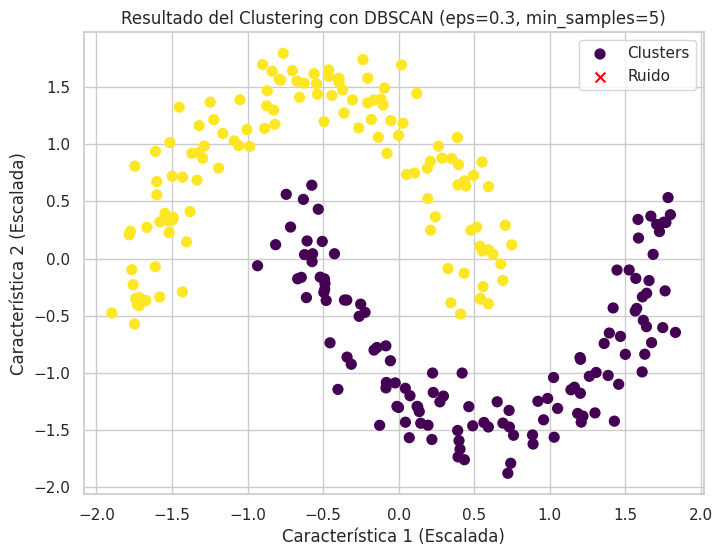

Número de clusters encontrados: 2
Número de puntos de ruido encontrados: 0


In [65]:
# Graficar los resultados
plt.figure(figsize=(8, 6))

# Los puntos marcados como -1 son ruido
noise_mask = y_dbscan == -1
clusters_mask = y_dbscan != -1

plt.scatter(X_moons_scaled[clusters_mask, 0], X_moons_scaled[clusters_mask, 1], c=y_dbscan[clusters_mask], s=50, cmap='viridis', label='Clusters')
plt.scatter(X_moons_scaled[noise_mask, 0], X_moons_scaled[noise_mask, 1], c='red', s=50, marker='x', label='Ruido')

plt.title(f"Resultado del Clustering con DBSCAN (eps=0.3, min_samples=5)")
plt.xlabel("Característica 1 (Escalada)")
plt.ylabel("Característica 2 (Escalada)")
plt.legend()
plt.show()

print(f"Número de clusters encontrados: {len(set(y_dbscan[y_dbscan != -1]))}")
print(f"Número de puntos de ruido encontrados: {np.sum(y_dbscan == -1)}")

## 2. Reducción de la Dimensionalidad

Cuando trabajamos con datasets que tienen muchas características (alta dimensionalidad), podemos enfrentar problemas como la "maldición de la dimensionalidad", mayor coste computacional y dificultad para visualizar. La reducción de dimensionalidad busca reducir el número de características manteniendo la mayor cantidad de información relevante posible.

---

### 2.1. Análisis de Componentes Principales (PCA)

**Concepto:**
PCA es una técnica lineal que transforma los datos a un nuevo sistema de coordenadas donde las nuevas características (componentes principales) capturan la máxima varianza posible de los datos y no están correlacionadas entre sí.
1.  Estandariza los datos (media 0, varianza 1).
2.  Calcula la matriz de covarianza.
3.  Calcula los eigenvectores y eigenvalores de la matriz de covarianza.
4.  Los eigenvectores (ordenados por sus eigenvalores correspondientes de mayor a menor) definen las direcciones de los nuevos ejes (componentes principales). El eigenvalor indica la cantidad de varianza explicada por ese componente.
5.  Se proyectan los datos originales sobre los primeros `k` componentes principales para reducir la dimensionalidad a `k`.

**¿Cuántos componentes elegir?** Se suele mirar la "varianza explicada acumulada". Por ejemplo, elegir suficientes componentes para explicar el 90% o 95% de la varianza total.

**Ventajas:**
*   Efectivo para reducir dimensiones eliminando redundancia (correlación).
*   No requiere parámetros complejos (solo el número de componentes deseado).
*   Útil para visualización (reduciendo a 2 o 3D) y como preprocesamiento para otros algoritmos.

**Desventajas:**
*   Asume linealidad en las relaciones entre características.
*   Los componentes principales resultantes pueden no ser fácilmente interpretables en términos de las características originales.
*   Sensible a la escala de los datos (¡importante escalar!).

In [66]:
# Ejemplo Ilustrativo de PCA
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

# Escalar los datos
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)


In [67]:
# Aplicar PCA para reducir a 2 componentes
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_iris_scaled)

In [68]:
# Varianza explicada por cada componente
print(f"Varianza explicada por componente: {pca.explained_variance_ratio_}")
print(f"Varianza explicada acumulada: {np.sum(pca.explained_variance_ratio_)}")

Varianza explicada por componente: [0.72962445 0.22850762]
Varianza explicada acumulada: 0.9581320720000166


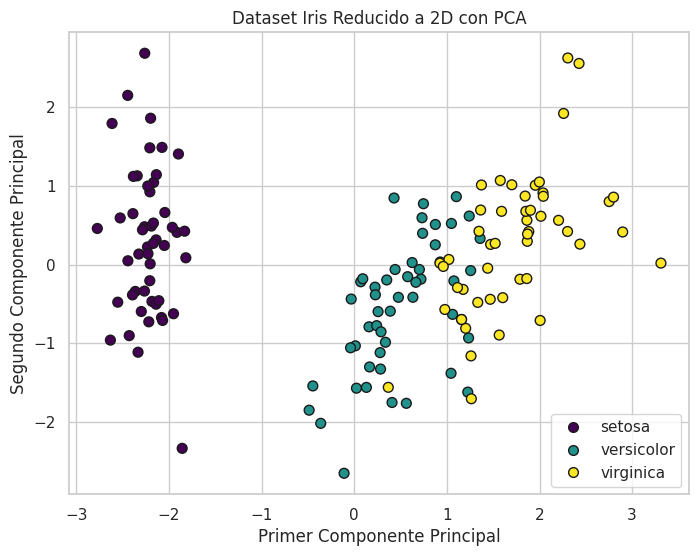

In [69]:
# Graficar los datos reducidos a 2D
plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_iris, cmap='viridis', edgecolor='k', s=50)
plt.title('Dataset Iris Reducido a 2D con PCA')
plt.xlabel('Primer Componente Principal')
plt.ylabel('Segundo Componente Principal')

# Get unique labels and handles for the legend
unique_labels = np.unique(iris.target_names) # Ensure unique labels
handles = [plt.Line2D([], [], color=scatter.cmap(scatter.norm(i)), marker='o', linestyle='', markersize=7, markeredgecolor='k') for i in np.unique(y_iris)]

plt.legend(handles, unique_labels) # Pass handles and labels to legend
plt.grid(True)
plt.show()

### 3.2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Concepto:**
t-SNE es una técnica no lineal utilizada principalmente para la **visualización** de datos de alta dimensionalidad en espacios de baja dimensión (generalmente 2D o 3D). Funciona modelando las similitudes entre puntos de datos en el espacio original y tratando de encontrar una representación de baja dimensión que preserve esas similitudes locales.

**Parámetros Clave:**
*   `n_components`: Dimensión del espacio embebido (usualmente 2 o 3).
*   `perplexity`: Relacionado con el número de vecinos cercanos que cada punto considera. Valores típicos entre 5 y 50. Afecta el balance entre aspectos locales y globales.
*   `learning_rate`: Controla cuánto se ajustan los puntos en cada iteración.
*   `n_iter`: Número de iteraciones.

**Ventajas:**
*   Excelente para revelar estructuras locales y clústeres en los datos para visualización.
*   Puede manejar relaciones no lineales.

**Desventajas:**
*   **No es una técnica de reducción de dimensionalidad general:** Está optimizada para visualización, no para usar como entrada a otros algoritmos. Las distancias entre clusters en el mapa t-SNE no siempre son significativas.
*   Computacionalmente intensivo, especialmente para datasets grandes.
*   Es estocástico (resultados pueden variar ligeramente entre ejecuciones).
*   Los resultados dependen bastante de los parámetros (especialmente `perplexity`).

In [70]:
# Ejemplo Ilustrativo de TSNE
from sklearn.datasets import load_iris

# Cargar el dataset Iris
iris = load_iris()
X_iris = iris.data
y_iris = iris.target
feature_names_iris = iris.feature_names

# Escalar los datos
scaler_iris = StandardScaler()
X_iris_scaled = scaler_iris.fit_transform(X_iris)

In [71]:
# Aplicar PCA para reducir a 2 componentes
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X_iris_scaled)

### 2.2. t-SNE (t-Distributed Stochastic Neighbor Embedding)

**Concepto:**
t-SNE es una técnica **no lineal** diseñada exclusivamente para **visualización** de datos de alta dimensionalidad en 2D o 3D. A diferencia de PCA (que busca preservar la varianza global), t-SNE preserva las **similitudes locales**: puntos que son vecinos cercanos en el espacio original también lo serán en el mapa 2D.

**¿Cómo funciona (intuitivo)?**
1.  Para cada par de puntos, calcula una probabilidad proporcional a su cercanía en el espacio original (usando una distribución Gaussiana).
2.  En el espacio 2D de salida, hace lo mismo pero con una distribución t de Student (de colas más anchas → más tolerante con distancias grandes).
3.  Ajusta las posiciones de los puntos en 2D para que las probabilidades del paso 1 y del paso 2 sean lo más parecidas posible (minimizando la divergencia KL entre ambas distribuciones).

La distribución t de Student en el espacio de salida es la clave: evita el "crowding problem" (apiñamiento), que ocurre cuando muchos puntos lejanos intentan mapear al mismo espacio reducido.

---

**Parámetros clave y cómo afectan el resultado:**

| Parámetro | Efecto | Rango típico |
|-----------|--------|-------------|
| `perplexity` | Controla cuántos vecinos cercanos considera cada punto. Perplexity baja → estructura muy local. Perplexity alta → estructura más global. | 5–50 |
| `learning_rate` | Velocidad de ajuste en cada iteración. Muy bajo: convergencia lenta. Muy alto: caos. | 10–1000 |
| `n_iter` | Más iteraciones → mejor convergencia, pero más lento. | ≥250 (default 1000) |
| `random_state` | Seed para reproducibilidad. Con diferente seed → diferente mapa. | cualquier entero |

**Efecto de la perplexity:**
- **Perplexity = 5:** Preserva solo estructuras muy locales (grupos pequeños y densos).
- **Perplexity = 30:** Balance entre local y global (recomendado para empezar).
- **Perplexity = 50:** Ve la estructura más global pero puede "aplastar" clusters pequeños.

---

**Advertencias importantes:**

> ⚠️ **Las distancias entre clusters en t-SNE NO son interpretables.** Que dos clusters estén cerca o lejos en el mapa t-SNE no significa que estén cerca o lejos en los datos originales.

> ⚠️ **El tamaño relativo de los clusters tampoco es confiable.** t-SNE tiende a hacer todos los clusters del mismo tamaño visual aunque tengan tamaños muy distintos.

> ⚠️ **El resultado cambia con cada ejecución** (es estocástico). Para comparar dos ejecuciones, usá el mismo `random_state`.

---

**¿Cuándo usar t-SNE?**
- Para explorar visualmente si hay estructura en los datos (¿hay clusters? ¿cuántos parecen ser?).
- Para comunicar resultados de clustering a audiencias no técnicas.
- **No** para preprocesar antes de otros algoritmos (usar PCA para eso).
- **No** para inferir distancias reales entre grupos.

**Alternativa moderna: UMAP**
UMAP (Uniform Manifold Approximation and Projection) es más rápido que t-SNE y tiende a preservar mejor tanto la estructura local como la global. Para datasets grandes (>50K puntos), UMAP es generalmente preferible a t-SNE.

| | t-SNE | UMAP |
|-|-------|------|
| Velocidad | Lento | Rápido |
| Estructura local | Excelente | Muy buena |
| Estructura global | Pobre | Mejor |
| Determinístico | No (con seed sí) | Sí (con seed) |
| Uso recomendado | Exploración visual, presentaciones | Producción, datasets grandes |

**Ventajas:**
*   Revela estructuras no lineales y clusters complejos que PCA no puede ver.
*   Visualizaciones muy intuitivas para detectar patrones.

**Desventajas:**
*   Solo sirve para visualización — no para reducción funcional de dimensiones.
*   Computacionalmente costoso (O(n²) en su versión exacta).
*   Resultados sensibles a la elección de parámetros.
*   No preserva distancias globales entre clusters.

## 4. Ejercicio Práctico: Segmentación de Clientes con K-Means

**Contexto:** Eres el manager de un centro comercial y necesitas segmentar a tus 200 clientes para crear estrategias de marketing diferenciadas.

**Tu objetivo:** Usar K-Means para agrupar clientes similares y luego... clasificarlos tú mism@.

---

### Paso 1: Cargar los Datos

Vamos a usar el dataset **Mall Customers** que contiene información de 200 clientes del shopping.

| Columna | Descripción |
|--------|----------|
| CustomerID | ID único del cliente |
| Genre | Género (Male/Female) |
| Age | Edad del cliente |
| Annual Income (k$) | Ingreso anual en miles de dólares |
| Spending Score (1-100) | Score de gasto calculado por el mall |


In [73]:
# Cargar el dataset desde URL pública
url = 'https://raw.githubusercontent.com/erkansirin78/datasets/master/Mall_Customers.csv'
df = pd.read_csv(url)

# Verificamos que se cargó correctamente
df.head()

,CustomerID,Gender,Age,AnnualIncome,SpendingScore
0,1,Male,19,15000,39
1,2,Male,21,15000,81
2,3,Female,20,16000,6
3,4,Female,23,16000,77
4,5,Female,31,17000,40


### Paso 2: Exploración de los Datos

Antes de aplicar clustering, necesitamos entender nuestra materia prima. Vamos a ver:
- ¿Cuántos clientes tenemos?
- ¿Qué edades tienen?
- ¿Cuánto ganan?
- ¿Cómo gastan?

Vemos la información básica y las estadísticas descriptivas.

In [74]:
# Información básica del dataset
print(f"Cantidad de clientes: {df.shape[0]}")
print(f"Columnas: {df.columns.tolist()}")
print()
# Estadísticas descriptivas
df.describe()

Cantidad de clientes: 200
Columnas: ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']



,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60560.000000,50.200000
std,57.879185,13.969007,26264.721165,25.823522
min,1.000000,18.000000,15000.000000,1.000000
25%,50.750000,28.750000,41500.000000,34.750000
50%,100.500000,36.000000,61500.000000,50.000000
75%,150.250000,49.000000,78000.000000,73.000000
max,200.000000,70.000000,137000.000000,99.000000


### Paso 3: Visualización de Distribución

Vamos a graficar la distribución de cada variable numérica para entender mejor a nuestros clientes.

Esto nos ayuda a:
- Ver si hay valores atípicos (outliers)
- Entender el rango de cada variable
- Identificar posibles patrones

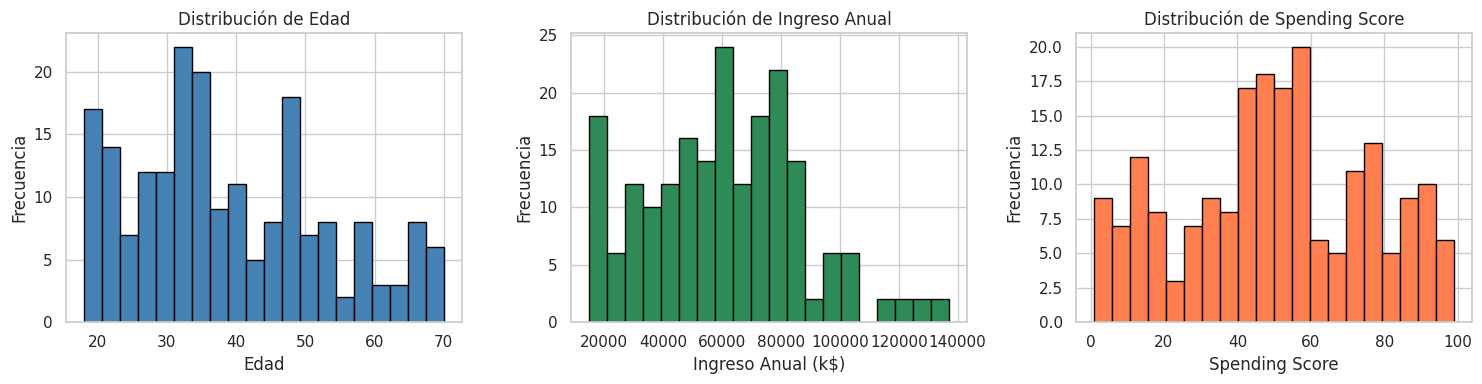

In [75]:
# Distribución de las variables numéricas
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Age
axes[0].hist(df['Age'], bins=20, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Edad')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')

# Annual Income
axes[1].hist(df['AnnualIncome'], bins=20, color='seagreen', edgecolor='black')
axes[1].set_title('Distribución de Ingreso Anual')
axes[1].set_xlabel('Ingreso Anual (k$)')
axes[1].set_ylabel('Frecuencia')

# Spending Score
axes[2].hist(df['SpendingScore'], bins=20, color='coral', edgecolor='black')
axes[2].set_title('Distribución de Spending Score')
axes[2].set_xlabel('Spending Score')
axes[2].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### Paso 4: Selección de Features para Clustering

Para este ejercicio, vamos a usar **dos variables**:
- **Annual Income (k$)** - Ingreso anual
- **Spending Score (1-100)** - Score de gasto

¿Por qué solo dos?
1. Son las más relevantes para segmentación de clientes
2. Permiten visualizar en 2D fácilmente
3. El Spending Score ya es un indicador de comportamiento que calculó el mall

> **Nota:** En un caso real, podrías usar más variables (Age, Genre, etc.), pero para aprender, mejor empezar simple.

In [76]:
# Seleccionamos las features para clustering
X = df[['AnnualIncome', 'SpendingScore']].values

# Escalar los datos (importante para K-Means)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Forma de los datos: {X_scaled.shape}")
print(f"Media (después de escalar): {X_scaled.mean(axis=0).round(2)}")
print(f"Desvío estándar (después de escalar): {X_scaled.std(axis=0).round(2)}")

Forma de los datos: (200, 2)
Media (después de escalar): [-0. -0.]
Desvío estándar (después de escalar): [1. 1.]


### Paso 5: Método del Codo

Antes de aplicar K-Means, necesitamos decidir **cuántos clusters (K)** usar.

El **Método del Codo** funciona así:
1. Ejecutamos K-Means para diferentes valores de K (1, 2, 3, ...)
2. Para cada K, medimos la **inercia** (suma de distancias al centroide más cercano)
3. Graficamos K vs Inercia
4. El "codo" = donde agregar más clusters ya no reduce mucho la inercia

Ejecutá la siguiente celda para encontrar el K óptimo.

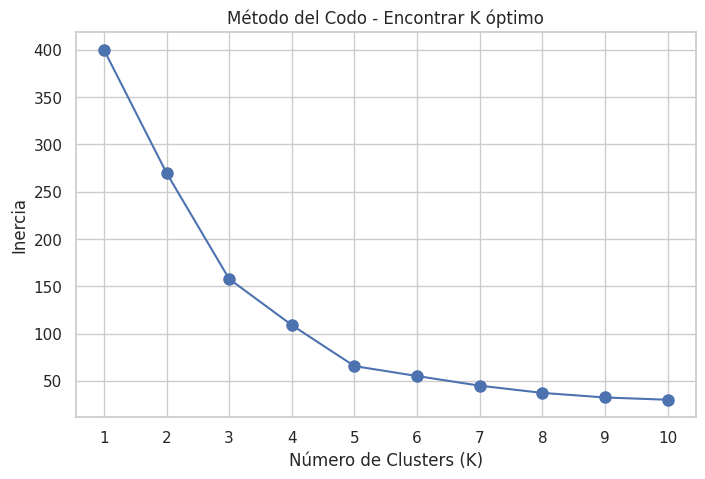


📊 ¿Dónde está el "codo"? Observá el gráfico y decidí cuántos clusters usar.


In [77]:
# Método del Codo
inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Graficar el codo
plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inercia')
plt.title('Método del Codo - Encontrar K óptimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

print('\n📊 ¿Dónde está el "codo"? Observá el gráfico y decidí cuántos clusters usar.')

### Paso 6: Decision - ¿Cuántos Clusters?

**Tu turno:**

Mirando el gráfico del codo, respondé:
- ¿Dónde parece estar el "codo"?
- ¿Qué K elegís y por qué?

---

**Pista:** El punto donde la curva empieza a aplanarse suele ser un buen indicador.

---

En el próximo paso, ejecutamos K-Means con el K que elijas. Ejecutá la siguiente celda con tu K elegido.

In [78]:
# Elegí tu K aquí (cambia el valor)
K = 5  # <-- CAMBIÁ ESTE VALOR si elegís otro K

# Aplicar K-Means
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
kmeans.fit(X_scaled)

# Obtener las etiquetas de cluster
labels = kmeans.labels_

# Agregar los clusters al DataFrame original
df['Cluster'] = labels

print(f"✅ K-Meansapplied with K={K}")
print(f"\nDistribución de clientes por cluster:")
print(df['Cluster'].value_counts().sort_index())

✅ K-Meansapplied with K=5

Distribución de clientes por cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


### Paso 7: Visualizar los Clusters

Ahora vamos a ver cómo quedaron nuestros clusters en un gráfico 2D.

Cada punto representa un cliente, y su color indica a qué cluster pertenece.
Las 'X' marcan los centroides de cada cluster.

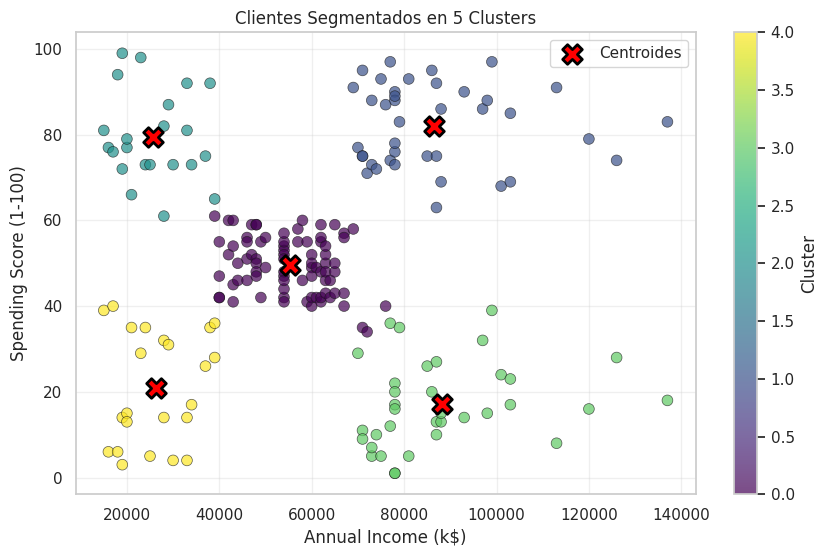

In [80]:
# Visualizar los clusters
plt.figure(figsize=(10, 6))

# Scatter plot con colores por cluster
scatter = plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster'],
    cmap='viridis',
    s=60,
    alpha=0.7,
    edgecolor='k',
    linewidth=0.5
)

# Centroides (en datos originales, no escalados)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    marker='X',
    s=200,
    edgecolor='black',
    linewidth=2,
    label='Centroides'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title(f'Clientes Segmentados en {K} Clusters')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Paso 8: Analizar cada Cluster

Llego la parte más interesante: **investigamos qué tiene cada cluster**.

Para cada cluster, vamos a ver:
- ¿Cuántos clientes tiene?
- ¿Cuál es la edad promedio?
- ¿Cuál es el ingreso promedio?
¿Cuál es el spending score promedio?

Esto nos va a dar pistas para **clasificar** cada grupo.

In [81]:
# Estadísticas por cluster
cluster_stats = df.groupby('Cluster').agg({
    'Cluster': 'count',
    'Age': 'mean',
    'AnnualIncome': 'mean',
    'SpendingScore': 'mean'
}).rename(columns={
    'Cluster': 'Cantidad',
    'Age': 'Edad Promedio',
    'AnnualIncome': 'Ingreso Promedio (k$)',
    'SpendingScore': 'Spending Score Promedio'
})

cluster_stats = cluster_stats.round(1)
print("📊 Estadísticas por Cluster:\n")
print(cluster_stats)
print()
# También ver rango de edad y de income
print("\n📈 Rangos por Cluster:")
for c in range(K):
    cluster_data = df[df['Cluster'] == c]
    print(f"\nCluster {c}:")
    print(f"  Edad: {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
    print(f"  Ingreso: {cluster_data['AnnualIncome'].min()} - {cluster_data['AnnualIncome'].max()} k$")
    print(f"  Spending: {cluster_data['SpendingScore'].min()} - {cluster_data['SpendingScore'].max()}")

📊 Estadísticas por Cluster:

         Cantidad  Edad Promedio  Ingreso Promedio (k$)  \
Cluster                                                   
0              81           42.7                55296.3   
1              39           32.7                86538.5   
2              22           25.3                25727.3   
3              35           41.1                88200.0   
4              23           45.2                26304.3   

         Spending Score Promedio  
Cluster                           
0                           49.5  
1                           82.1  
2                           79.4  
3                           17.1  
4                           20.9  


📈 Rangos por Cluster:

Cluster 0:
  Edad: 18 - 70
  Ingreso: 39000 - 76000 k$
  Spending: 34 - 61

Cluster 1:
  Edad: 27 - 40
  Ingreso: 69000 - 137000 k$
  Spending: 63 - 97

Cluster 2:
  Edad: 18 - 35
  Ingreso: 15000 - 39000 k$
  Spending: 61 - 99

Cluster 3:
  Edad: 19 - 59
  Ingreso: 70000 - 137000 k$
  

### Paso 9: Clasificar los Clusters

**¡Ahora viene lo más interesante!**

Basándote en los datos de cada cluster, assignale un **nombre** que lo defina.

---

**Ejemplos de clasificación:**

| Cluster | Característica | Nombre Sugerido |
|--------|-------------|----------------|
| 0 | Bajo ingreso, Bajo gasto | "Conservadores" |
| 1 | Alto ingreso, Alto gasto | "VIPs" |
| 2 | Medio ingreso, Medio gasto | "Clase Media" |

---

**Tu turno:** Creá una tabla con tus clasificaciones y explicá por qué elegiste cada nombre.

> 💡 **Tip:** Fijate en las combinaciones:
- Alto/Bajo Income + Alto/Bajo Spending = 4 combinaciones possíveis

In [ ]:
# TABLA DE CLASIFICACIÓN - COMPLETÁ CON TUS NOMBRES
# Ejemplo de estructura:
# classificacion = {
#     0: ('Nombre', 'Descripción'),
#     1: ('Nombre', 'Descripción'),
#     ...
# }

#Completá con tus clasificaciones:
clasificacion = {
    0: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    1: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    2: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    3: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
    4: ('PONÉ TU NOMBRE AQUÍ', 'Escribí por qué elegiste este nombre basándote en los datos'),
}

print("🎯 Mi clasificación de clusters:\n")
for cluster_id, (nombre, desc) in clasificacion.items():
    print(f"Cluster {cluster_id}: {nombre}")
    print(f"   → {desc}\n")

### Paso 10: Reflexión Final

---

**¿Qué aprendimos?**

1. ✅ Cargar y explorar datos reales
2. ✅ Aplicar el Método del Codo para elegir K
3. ✅ Usar K-Means para clustering
4. ✅ Analizar y caracterizar cada cluster
5. ✅ **Clasificar** basándonos en los datos (no en intuición)

---

**Para pensar:**

- ¿El K que elegiste fue el óptimo?
- ¿Cómo cambiarían las clasificaciones si elegieras otro K?
- ¿Qué estrategias de marketing propondrías para cada segmento?

---

> 🎓 **Conclusión:** El clustering nos da grupos, pero la clasificación (poner nombre) la Hacemos NOSOTROS. Por eso es importante investigar los datos antes de concluir.